In [ ]:
# Dataset citation: Skrynnyk, M., Disassa, G., Krachkov, A., & DeVera, J. (2024). SDGi Corpus: A Comprehensive Multilingual Dataset for Text Classification by Sustainable Development Goals. Proceedings of the 2nd Symposium on NLP for Social Good, CEUR Workshop Proceedings 3764, 32–42. https://ceur-ws.org/Vol-3764/paper3.pdf

In [ ]:
# Imports and simple EDA helpers
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_ROOT = Path("..")

def inspect_table(df, name, preview_columns=None):
    print(f"\n{name}: {len(df):,} rows x {len(df.columns):,} columns")
    cols = preview_columns or list(df.columns[:8])
    shown = df[cols]
    display(pd.DataFrame({"column": shown.columns, "dtype": [str(x) for x in shown.dtypes],
                          "missing": shown.isna().sum().values,
                          "missing_%": (shown.isna().mean().values * 100).round(2),
                          "unique": shown.astype(str).nunique(dropna=True).values}))
    print(f"Duplicate rows on shown columns: {shown.astype(str).duplicated().sum():,}")
    display(shown.head(5))

def plot_counts(counts, title, xlabel="Class", ylabel="Rows"):
    counts = counts.sort_index()
    display(counts.rename("count").to_frame())
    ax = counts.plot(kind="bar", figsize=(11, 4), color="#4472C4")
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def text_stats(df, column):
    if column not in df.columns:
        return
    values = df[column].fillna("").astype(str)
    lengths = values.str.len()
    words = values.str.split().str.len()
    print(f"\nText field: {column}")
    display(pd.DataFrame({"characters": lengths.describe(), "words": words.describe()}))
    print("Empty text rows:", int(values.str.strip().eq("").sum()))

In [ ]:
# Load train and test
from collections import Counter
train = pd.read_parquet(DATA_ROOT / "sdgi-corpus/data/train-00000-of-00001.parquet")
test = pd.read_parquet(DATA_ROOT / "sdgi-corpus/data/test-00000-of-00001.parquet")

In [ ]:
# Train and test sizes
display(pd.DataFrame({"split": ["train", "test"], "rows": [len(train), len(test)]}))

,split,rows
0,train,5880
1,test,1470


In [ ]:
# Training table
inspect_table(train, "Train", ["text", "labels"])


Train: 5,880 rows x 4 columns


,column,dtype,missing,missing_%,unique
0,text,object,0,0.0,5880
1,labels,object,0,0.0,407


Duplicate rows on shown columns: 0


,text,labels
0,END POVERTY\r\nIN ALL ITS FORMS \r\nEVERYWHERE...,[1]
1,PONER FIN A LA POBREZA\r\nEN TODAS SUS FORMAS ...,[1]
2,End poverty in all its \r\nforms everywhere\r\...,[1]
3,Poner fin a la pobreza\r\nen todas sus formas\...,[1]
4,"15\r\nWith regard to this SDG in particular, i...",[1]


In [ ]:
# Test table
inspect_table(test, "Test", ["text", "labels"])


Test: 1,470 rows x 4 columns


,column,dtype,missing,missing_%,unique
0,text,object,0,0.0,1470
1,labels,object,0,0.0,156


Duplicate rows on shown columns: 0


,text,labels
0,80 Voluntary Local Review 2022 | City of Bonn ...,[1]
1,75\r\n 1 Care and integration of refugees and ...,[1]
2,"1 Prevention of child, youth and old-age pover...",[1]
3,82 Voluntary Local Review 2022 | City of Düsse...,[1]
4,76 Voluntary Local Review 2022 | City of Düsse...,[1]


In [ ]:
# Text length
text_stats(train, "text")
text_stats(test, "text")


Text field: text


,characters,words
count,5880.000000,5880.000000
mean,8584.092857,1269.248810
std,8172.927108,1215.959346
min,115.000000,26.000000
25%,2534.000000,372.000000
50%,6567.000000,964.500000
75%,11997.250000,1767.250000
max,114745.000000,17529.000000


Empty text rows: 0

Text field: text


,characters,words
count,1470.000000,1470.000000
mean,12539.987755,1831.836054
std,17338.509235,2582.340810
min,238.000000,25.000000
25%,2333.750000,328.250000
50%,5790.500000,840.500000
75%,14281.500000,2066.250000
max,125552.000000,18369.000000


Empty text rows: 0


In [ ]:
# Class counts by split
def label_counts(frame):
    return pd.Series(Counter(label for row in frame["labels"] for label in row), dtype="int64")
display(pd.concat({"train": label_counts(train), "test": label_counts(test)}, axis=1).fillna(0).astype(int).sort_index())

,train,test
1,452,123
2,437,97
3,578,132
4,532,134
5,487,81
6,395,80
7,420,64
8,548,168
9,467,140
10,485,170


,count
1,452
2,437
3,578
4,532
5,487
6,395
7,420
8,548
9,467
10,485


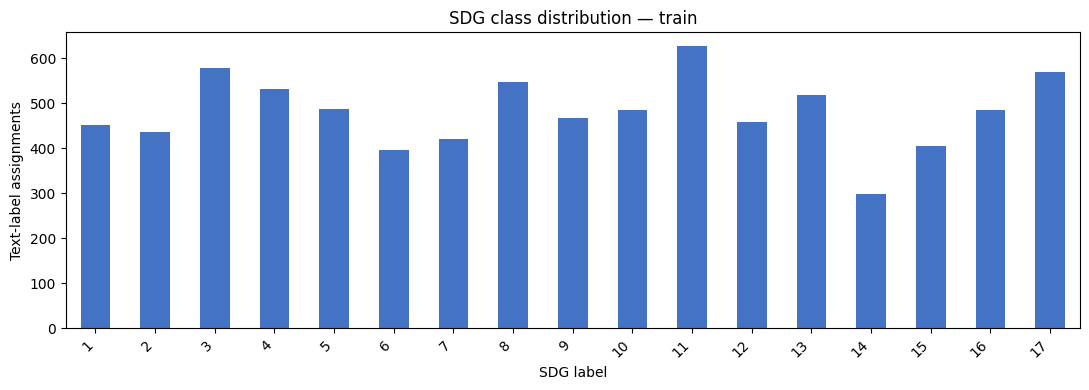

In [ ]:
#  Training class distribution
plot_counts(label_counts(train), "SDG class distribution — train", "SDG label", "Text-label assignments")

,count
1,123
2,97
3,132
4,134
5,81
6,80
7,64
8,168
9,140
10,170


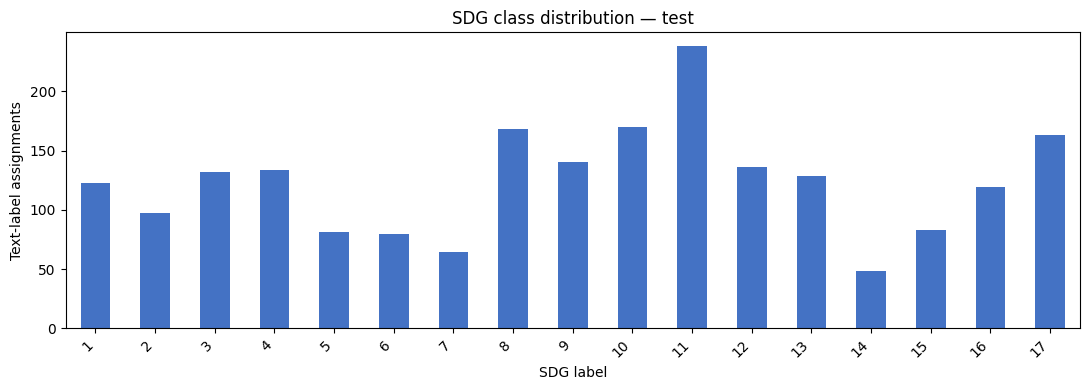

In [ ]:
#  Test class distribution
plot_counts(label_counts(test), "SDG class distribution — test", "SDG label", "Text-label assignments")

In [ ]:
# Labels per text
display(train["labels"].map(len).value_counts().sort_index().rename_axis("labels_per_text").to_frame("rows"))

,rows
labels_per_text,
1,5233
2,137
3,132
4,146
5,98
6,33
7,34
8,17
9,8


In [ ]:
# Metadata counts
for key in ["language", "type", "year", "country"]:
    values = train["metadata"].map(lambda value: value.get(key) if isinstance(value, dict) else None)
    print(key)
    display(values.value_counts(dropna=False).head(25).to_frame("rows"))

language


,rows
metadata,
en,4225
es,935
fr,720


type


,rows
metadata,
vnr,4001
vlr,1879


year


,rows
metadata,
2020,1157
2021,1040
2022,1039
2023,794
2018,746
2019,600
2017,401
2016,103


country


,rows
metadata,
esp,317
deu,236
mex,196
fin,181
bra,179
arg,172
bel,147
mys,107
swe,92
